In [62]:
import pandas as pd
from collections import defaultdict
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind
from itertools import combinations
from utils import *

In [63]:
raw_counts_sarcopenia = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/sarcopenia_bulk_RNA/GSE226151_SKELETAL_MUSCLE_READ_COUNT.txt'
series_matrix_sarcopenia = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/sarcopenia_bulk_RNA/GSE226151_series_matrix.txt'
# read txt into a df
sarcopenia_counts = pd.read_csv(raw_counts_sarcopenia, sep='\t')

In [64]:
lines = read_series_matrix(series_matrix_sarcopenia)
metadata_dict = parse_sample_metadata(lines)
mapping_df = clean_metadata_df(metadata_dict)
# expression_df = pd.read_csv("expression_matrix.tsv")  # Load separately
female_expr_df, male_expr_df = split_expression_by_sex(sarcopenia_counts, mapping_df)


In [65]:
mapping_df.head()

,sample_id,sex,disease_state,label
0,"""Skeletal muscle, HA 01""",Female,healthy aged,HA_1
1,"""Skeletal muscle, HA 02""",Female,healthy aged,HA_2
2,"""Skeletal muscle, HA 03""",Female,healthy aged,HA_3
3,"""Skeletal muscle, HA 04""",Female,healthy aged,HA_4
4,"""Skeletal muscle, HA 05""",Female,healthy aged,HA_5


In [80]:
def load_gmt(filepath):
    """
    Load a GMT file into a dictionary of {pathway_name: list_of_genes}
    """
    gene_sets = {}
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                pathway = parts[0]
                genes = parts[2:]  # Skip the description (parts[1])
                gene_sets[pathway] = genes
    return gene_sets

def calculate_geneset_score(data, up_genes=None, down_genes=None, mapping_df=None):
    """
    Calculate geneset signature scores for each sample based on gene sets.
    Optionally attaches disease state if mapping_df is provided.
    """
    import numpy as np
    import pandas as pd

    if up_genes is None and down_genes is None:
        raise ValueError("At least one of up_genes or down_genes must be provided")

    # Set index to gene names if not already done
    if "Name" in data.columns:
        data = data.set_index("Name")
    if "Description" in data.columns:
        data = data.drop("Description", axis=1)

    # Check which genes are present
    available_genes = set(data.index)

    if up_genes is not None:
        up_genes = list(set(up_genes).intersection(available_genes))
        print(f"Using {len(up_genes)} upregulated genes")

    if down_genes is not None:
        down_genes = list(set(down_genes).intersection(available_genes))
        print(f"Using {len(down_genes)} downregulated genes")

    if (not up_genes) and (not down_genes):
        raise ValueError("No genes from gene sets found in expression data")

    sample_names = data.columns
    expr_matrix = data.select_dtypes(include=[np.number])

    # Z-standardize expression across samples (per gene)
    z = (expr_matrix - expr_matrix.mean(axis=1).values.reshape(-1, 1)) / expr_matrix.std(axis=1).values.reshape(-1, 1)

    # Score calculation
    scores = pd.Series(0, index=sample_names, dtype=float)
    total_genes = (len(up_genes) if up_genes else 0) + (len(down_genes) if down_genes else 0)

    if up_genes:
        scores += z.loc[up_genes].sum()
    if down_genes:
        scores -= z.loc[down_genes].sum()

    scores /= np.sqrt(total_genes)  # Normalize by gene set size
    scores = (scores - scores.mean()) / scores.std()  # Z-score across samples

    scores_df = pd.DataFrame({"geneset_score": scores})

    # If mapping is provided, merge in disease state
    if mapping_df is not None:
        scores_df = scores_df.reset_index().rename(columns={"index": "label"})
        mapping_df = mapping_df[["label", "disease_state"]].drop_duplicates()
        scores_df = scores_df.merge(mapping_df, on="label", how="left").set_index("label")

    return scores_df

def plot_geneset_scores_scatter(scores_df, category_col="disease_state", palette=None, title=None, ylabel=None):
    """
    Create a scatter plot of gene set scores with colored sample labels by category.
    
    Parameters:
    - scores_df: DataFrame with index = sample label, and columns: 'geneset_score' and [category_col]
    - category_col: str, column to color by (e.g., 'disease_state')
    - palette: dict, mapping of category → color (REQUIRED)
    - title: str, optional plot title
    - ylabel: str, optional y-axis label
    """
    import matplotlib.pyplot as plt

    assert palette is not None, "You must provide a palette dictionary to ensure consistent coloring."

    plt.figure(figsize=(12, 6))
    
    # Sort by gene set score for visual ordering
    scores_sorted = scores_df.sort_values("geneset_score")

    # Plot invisible points to fix axes
    plt.scatter(
        range(len(scores_sorted)), 
        scores_sorted["geneset_score"], 
        alpha=0  # invisible markers
    )

    # Annotate each sample
    for i, (sample, row) in enumerate(scores_sorted.iterrows()):
        category = row[category_col]
        plt.annotate(
            sample,
            (i, row["geneset_score"]),
            color=palette[category],
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=10,
        )

    # Custom legend
    legend_elements = [
        plt.Line2D([0], [0], marker="o", color="none", label=cat, markerfacecolor=color, markersize=8)
        for cat, color in palette.items()
    ]
    plt.legend(handles=legend_elements, title=category_col, loc="center left", bbox_to_anchor=(1, 0.5))

    # Formatting
    plt.grid(True, alpha=0.3)
    plt.xlabel("Samples (ordered by score)")
    plt.ylabel(ylabel if ylabel else "Gene Set Score", weight="bold")
    plt.title(title if title else "Gene Set Scores per Sample", pad=10)
    plt.xticks([])
    plt.tight_layout()
    plt.show()

def calculate_pairwise_significance(data, x_var, y_var):
    """
    Perform pairwise t-tests and return significance annotations.
    """
    results = {}
    groups = data[x_var].unique()
    group_indices = {group: i for i, group in enumerate(groups)}
    
    for group1, group2 in combinations(groups, 2):
        values1 = data[data[x_var] == group1][y_var]
        values2 = data[data[x_var] == group2][y_var]
        stat, p = ttest_ind(values1, values2, equal_var=False)
        if p < 0.001:
            sig = '***'
        elif p < 0.01:
            sig = '**'
        elif p < 0.05:
            sig = '*'
        else:
            sig = 'ns'
        results[(group_indices[group1], group_indices[group2])] = {
            "p-value": p,
            "significance": sig
        }
    return results

def plot_geneset_score_violin_box(scores_df, category_col="disease_state", score_col="geneset_score", palette=None, title=None):
    """
    Plot geneset scores across categories using combined violin-box-strip plot.
    
    Parameters:
    - scores_df: DataFrame with columns [category_col, score_col]
    - category_col: column with categorical grouping (e.g. disease_state)
    - score_col: column with numeric gene set score
    - palette: dict of colors for each category (REQUIRED)
    - title: optional plot title
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import ttest_ind
    from itertools import combinations

    assert palette is not None, "You must pass a color palette dictionary for consistent category coloring."

    def calculate_pairwise_significance(data, x_var, y_var):
        results = {}
        groups = data[x_var].unique()
        group_indices = {group: i for i, group in enumerate(groups)}
        for g1, g2 in combinations(groups, 2):
            x1 = data[data[x_var] == g1][y_var]
            x2 = data[data[x_var] == g2][y_var]
            stat, p = ttest_ind(x1, x2, equal_var=False)
            if p < 0.001: sig = '***'
            elif p < 0.01: sig = '**'
            elif p < 0.05: sig = '*'
            else: sig = 'ns'
            results[(group_indices[g1], group_indices[g2])] = {"p-value": p, "significance": sig}
        return results

    plt.clf()
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.subplots_adjust(left=0.15, right=0.85, bottom=0.1, top=0.9)

    # Violin plot
    sns.violinplot(
        data=scores_df, x=category_col, y=score_col,
        palette=palette, inner=None, linewidth=0, alpha=0.3, width=0.5, cut=0, ax=ax
    )

    # Box plot
    sns.boxplot(
        data=scores_df, x=category_col, y=score_col,
        palette=palette, fliersize=0, linewidth=1.2, width=0.3, ax=ax
    )

    # Strip plot
    sns.stripplot(
        data=scores_df, x=category_col, y=score_col,
        palette=palette, size=6, jitter=0.25, linewidth=0, ax=ax, zorder=3
    )

    # Significance bars
    significance = calculate_pairwise_significance(scores_df, category_col, score_col)
    y_max = scores_df[score_col].max()
    bar_height = y_max + 0.5
    bar_gap = 0.3

    for (i, j), result in significance.items():
        if result["significance"] != "ns":
            ax.plot([i, i, j, j],
                    [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height],
                    color='black', linewidth=1.0)
            ax.text((i + j) / 2, bar_height + 0.07,
                    f"{result['significance']} (p={result['p-value']:.3g})",
                    ha='center', va='bottom', fontsize=9)
            bar_height += bar_gap

    ax.set_ylim(scores_df[score_col].min() - 0.5, bar_height + 0.1)
    ax.set_xlabel("")
    ax.set_ylabel("Gene Set Score", weight='bold')
    ax.set_title(title or "Gene Set Score by Category", pad=15)

    sns.despine()
    plt.tight_layout()
    plt.show()


In [83]:
gene_sets = load_gmt("/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt")
palette = {
    "healthy aged": "#1f77b4",
     "pre-sarcopenia": "#ff7f0e",     # orange
    "sarcopenia": "#d62728"
}
# Select one pathway to score
genes_for_pathway = gene_sets["HALLMARK_DNA_REPAIR"]  # this is a list
score_df = calculate_geneset_score(male_expr_df, up_genes=genes_for_pathway, mapping_df=mapping_df)

Using 150 upregulated genes


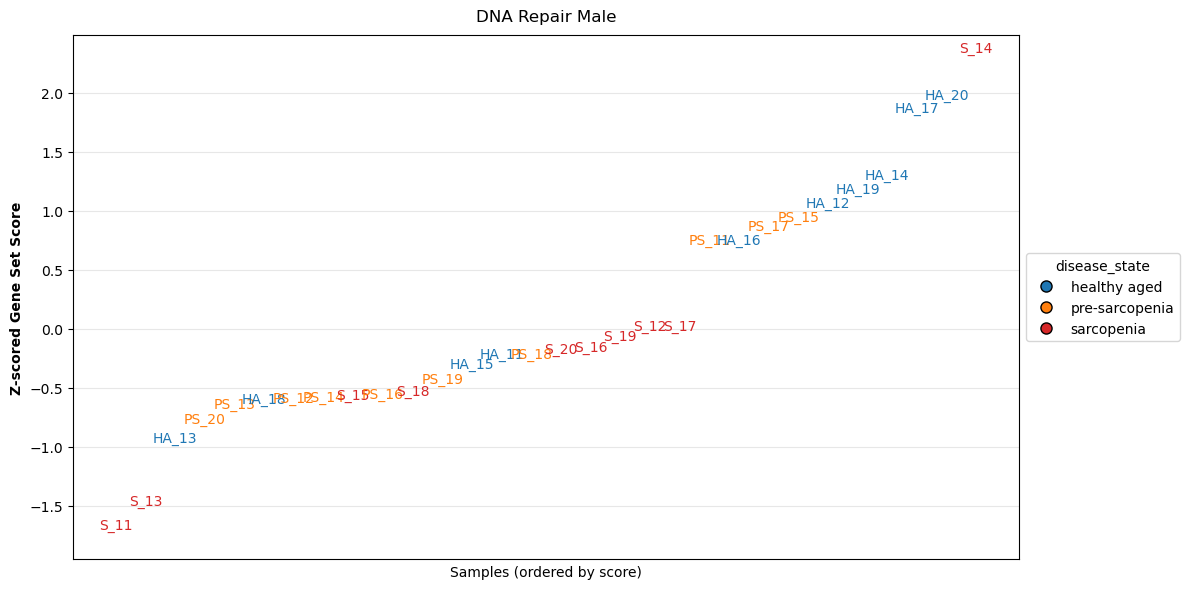

In [84]:
plot_geneset_scores_scatter(
    score_df, 
    category_col="disease_state", 
    title="DNA Repair Male",
    ylabel="Z-scored Gene Set Score",
    palette=palette
)


/tmp/ipykernel_102411/1482998268.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=scores_df, x=category_col, y=score_col, inner=None, palette=palette, cut=0, linewidth=0, alpha=0.3, width=0.5, ax=ax)
/tmp/ipykernel_102411/1482998268.py:180: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scores_df, x=category_col, y=score_col, width=0.3, palette=palette, fliersize=0, boxprops={'zorder': 2}, ax=ax)
/tmp/ipykernel_102411/1482998268.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=scores_df, x=category_col, y=score_c

<Figure size 640x480 with 0 Axes>

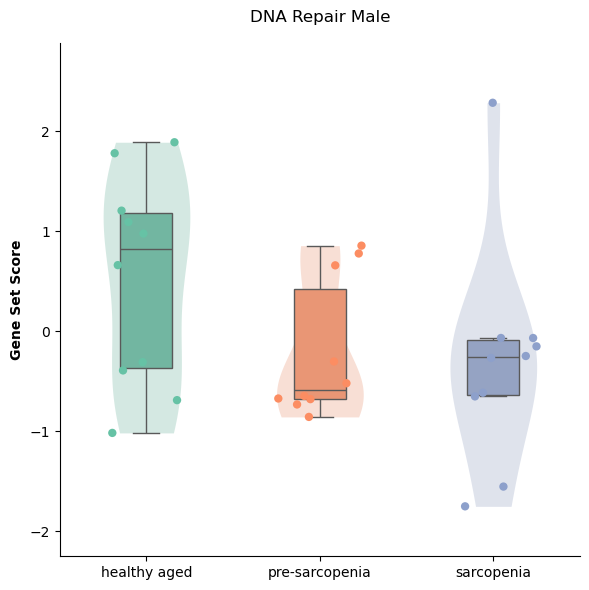

In [77]:
plot_geneset_score_violin_box(
    score_df,
    category_col="disease_state",
    title="DNA Repair Male"
)
